#### **BUSINESS UNDERSTANDING**
The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine. We then apply them in a data mining approach to predict human wine taste preferences that is based on easily available analytical tests. 

The purpose of this study is to find out if it is possible to predict what score a wine would be given based on its chemical properties and wine testers’ opinion on the wine quality. 
This opens up the possibility of assigning wine scores without the use of pricey professional wine testers. 
Wine quality is attributed to many different factors of the wine working collectively to bear a sensory experience that is not apparent from considering these components in isolation. The various chemical components in wine give the wine its distinct taste and aroma.

*For more information: Modeling wine preferences by data mining from physicochemical properties
By P. Cortez, A. Cerdeira, Fernando Almeida, Telmo Matos, J. Reis. 2009*

*Source: https://archive.ics.uci.edu/dataset/186/wine+quality*

### ***Loading Libraries***

In [8]:
import pandas as pd # data manipulation and reading the dat as a dataframe
import numpy as np # for numerical analysis 
import seaborn as sns # visualizations
from sklearn.model_selection import train_test_split # we split the data to use it well 
from sklearn.metrics import r2_score, accuracy_score # evaluation metric  - R^2 
import matplotlib.pyplot as plt # aids in visualization
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler # scaling towards a mean = 0 and sd = 1
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score # evaluation metric  - R^2 
from sklearn.model_selection import cross_val_score # cross validation
from sklearn.linear_model import LogisticRegression 


### ***Loading Data***

In [9]:
df_red_wine = pd.read_csv("Data\\winequality-red.csv", sep=";") # read the data as a dataframe
df_white_wine = pd.read_csv("Data\\winequality-white.csv", sep=";") # read the data as a dataframe

In [10]:
df_red_wine["wine type"] = "red"
df_white_wine["wine type"] = "white"

In [11]:
df_wine = pd.concat([df_red_wine, df_white_wine], axis=0, ignore_index=True) # combine the two dataframes into one

### ***Data Understanding***

In [12]:
df_red_wine.head() # display the first 5 records of the red wine dataset

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [13]:
df_white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine type
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white


In [14]:
df_wine.head() # display the first 5 records of the combined wine dataset

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [15]:
df_wine.tail() # display the last 5 records of the combined wine dataset

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine type
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white
6496,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,white


In [16]:
rows_red, features_red = df_red_wine.shape
rows_white, features_white = df_white_wine.shape
rows_wine, features_wine = df_wine.shape
print(f"The red wine dataset has {rows_red} records and {features_red} features.")
print(f"The white wine dataset has {rows_white} records and {features_white} features.")
print(f"The combined wine dataset has {rows_wine} records and {features_wine} features.")


The red wine dataset has 1599 records and 13 features.
The white wine dataset has 4898 records and 13 features.
The combined wine dataset has 6497 records and 13 features.


In [17]:
df_wine.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine type             6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


### **Data Preparation**

In [18]:
encoded_df_wine = df_wine["wine type"].map({'red': 1, 'white': 0})
encoded_df_wine

0       1
1       1
2       1
3       1
4       1
       ..
6492    0
6493    0
6494    0
6495    0
6496    0
Name: wine type, Length: 6497, dtype: int64

In [19]:
df_wine_2 = df_wine.reset_index(drop=True) #reset the index of the df_wine dataframe to start from 0 and drop the old index column

encoded_df_wine = encoded_df_wine.reset_index(drop=True) #reset the index of the encoded df

df_wine_final= pd.concat([df_wine_2.drop(columns=['wine type']), encoded_df_wine], axis=1) # combine the two df's

In [20]:
df_wine_final.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [21]:
df_wine_final.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine type
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,0
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,0
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,0
6496,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,0


### *Simple Linear Regression: Univariate Analysis*

In [22]:
df_wine_final.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'wine type'],
      dtype='str')

### *Simple Linear Regression: Bivariate Analysis*

In [23]:
analysis_df_1 = df_wine_final[['quality', 'fixed acidity']]

In [24]:
analysis_df_1.head()

,quality,fixed acidity
0,5,7.4
1,5,7.8
2,5,7.8
3,6,11.2
4,5,7.4


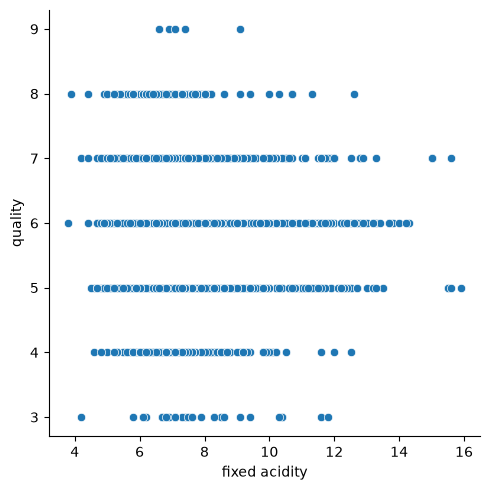

In [25]:
sns.relplot(data=analysis_df_1, x='fixed acidity', y='quality')

In [26]:
analysis_df_2 = df_wine_final[['quality', 'residual sugar']]

In [27]:
analysis_df_2.head()

,quality,residual sugar
0,5,1.9
1,5,2.6
2,5,2.3
3,6,1.9
4,5,1.9


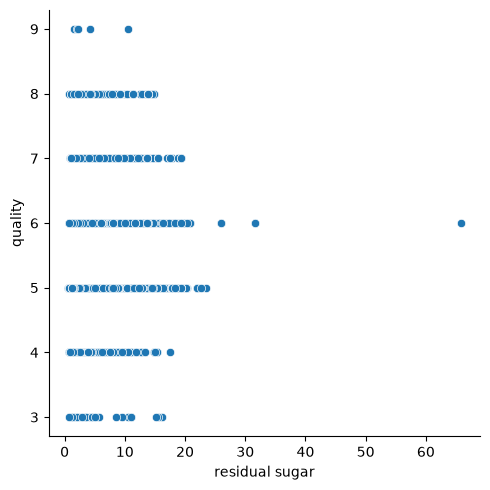

In [28]:
sns.relplot(data=analysis_df_2, x='residual sugar', y='quality')

In [29]:
x = pd.DataFrame(analysis_df_2['residual sugar'])
y = pd.DataFrame(analysis_df_2['quality'])

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=30, random_state=42)

In [31]:
linear_reg_model = LinearRegression()

In [32]:
linear_reg_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[-0.01]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['residual sugar']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[5.85]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [33]:
y_predicted = linear_reg_model.predict(x_test)
y_predicted

array([[5.76601202],
       [5.83947256],
       [5.80343531],
       [5.77710041],
       [5.75838876],
       [5.84016558],
       [5.73205385],
       [5.79511903],
       [5.83808651],
       [5.83670046],
       [5.71750035],
       [5.84501675],
       [5.81521672],
       [5.83947256],
       [5.8436307 ],
       [5.81868184],
       [5.84016558],
       [5.77294226],
       [5.80828648],
       [5.74106316],
       [5.80620741],
       [5.80759346],
       [5.80967253],
       [5.79234693],
       [5.76393295],
       [5.80551439],
       [5.78195157],
       [5.7479934 ],
       [5.84155163],
       [5.83877953]])

In [34]:
r2_score(y_test, y_predicted)

-0.10709543351833672

### *Linear Regression: Multivariate Analysis*

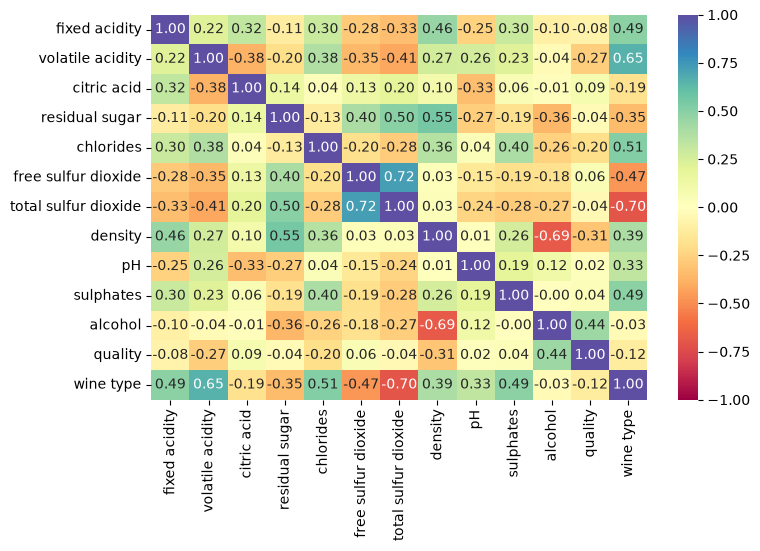

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))#adjusting the size of the figure

sns.heatmap(df_wine_final.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral") #ploting the heat map
plt.show()

In [36]:
y_multilinear = df_wine_final['quality']

In [37]:
x_multilinear = df_wine_final.drop(columns=['quality'])
x_multilinear

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,wine type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,0
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,0
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,0
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,0


In [38]:
x_train, x_test, y_train, y_test = train_test_split(x_multilinear, y_multilinear, test_size=30, random_state=42)

In [39]:
x_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,wine type
1397,7.3,0.59,0.26,2.00,0.080,17.0,104.0,0.99584,3.28,0.52,9.9,1
2127,5.2,0.36,0.02,1.60,0.031,24.0,104.0,0.98960,3.44,0.35,12.2,0
1263,8.2,0.78,0.00,2.20,0.089,13.0,26.0,0.99780,3.37,0.46,9.6,1
1963,6.8,0.16,0.40,2.30,0.037,18.0,102.0,0.99230,3.49,0.42,11.4,0
706,7.0,0.78,0.08,2.00,0.093,10.0,19.0,0.99560,3.40,0.47,10.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3772,7.6,0.32,0.58,16.75,0.050,43.0,163.0,0.99990,3.15,0.54,9.2,0
5191,5.6,0.28,0.27,3.90,0.043,52.0,158.0,0.99202,3.35,0.44,10.7,0
5226,6.4,0.37,0.20,5.60,0.117,61.0,183.0,0.99459,3.24,0.43,9.5,0
5390,6.5,0.26,0.50,8.00,0.051,46.0,197.0,0.99536,3.18,0.47,9.5,0


In [40]:
y_train

1397    5
2127    6
1263    4
1963    7
706     5
       ..
3772    5
5191    7
5226    5
5390    5
860     5
Name: quality, Length: 6467, dtype: int64

In [41]:
multilinear_reg_model = LinearRegression()
multilinear_reg_model.fit(x_train, y_train)
multilinear_reg_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 0.09,-1.49,-0.06,..., 0.72, 0.22, 0.36]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['fixed acidity','volatile acidity','citric acid',...,'sulphates', 'alcohol','wine type']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,104.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12


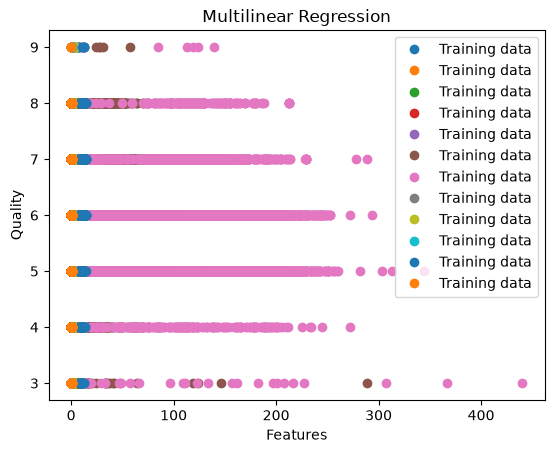

In [42]:
plt.plot(x_train, y_train, 'o', label='Training data')
plt.xlabel('Features')
plt.ylabel('Quality')
plt.title('Multilinear Regression')
plt.legend()
plt.show()  

##### ****Logistic Regression****

In [43]:
#standardize the features to have a mean of 0 and a standard deviation of 1 for logistic regression.
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print('Training set shape:', x_train_scaled.shape, 'Testing set shape:', x_test_scaled.shape)
print('Training set class distribution:\n', y_train.value_counts())
print('Testing set class distribution:\n', y_test.value_counts())

Training set shape: (6467, 12) Testing set shape: (30, 12)
Training set class distribution:
 quality
6    2825
5    2129
7    1071
4     216
8     191
3      30
9       5
Name: count, dtype: int64
Testing set class distribution:
 quality
6    11
5     9
7     8
8     2
Name: count, dtype: int64


In [44]:
logistic_model = LogisticRegression(class_weight='balanced', random_state=42)
logistic_scores = cross_val_score(logistic_model, x_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"{'Logistic Regression':22s} 5-fold CV F1 (good class): mean={logistic_scores.mean():.3f}  std={logistic_scores.std():.3f}")

c:\Users\Mwangi Maina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Mwangi Maina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
   

Logistic Regression    5-fold CV F1 (good class): mean=0.332  std=0.020


c:\Users\Mwangi Maina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [45]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.3, 
    random_state=42, 
    stratify= y # it will retain a constant proportion when splitting the two classes
)

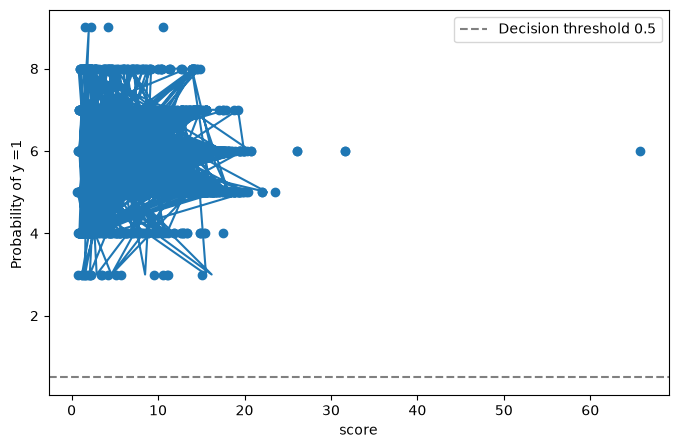

In [46]:
plt.figure(figsize=(8,5))  
plt.scatter(x_train, y_train)
plt.plot(x_test, y_test)
plt.axhline(0.5, color="grey", linestyle='--', label='Decision threshold 0.5')
plt.xlabel('score')
plt.ylabel('Probability of y =1 ')
plt.legend()
plt.show()

##### ****Decision Tree****

In [47]:
counts = df_wine_final['wine type'].value_counts().sort_index()
counts

wine type
0    4898
1    1599
Name: count, dtype: int64

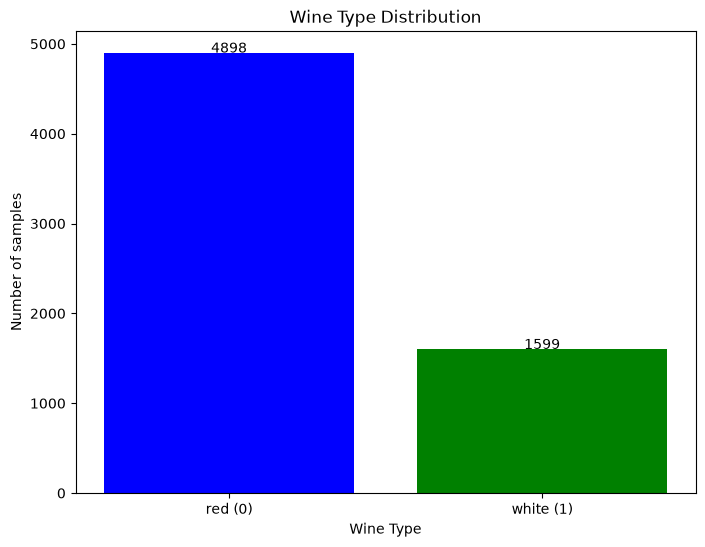

In [48]:
plt.figure(figsize=(8,6)) # usually manipulates the size
plt.bar(['red (0)','white (1)'], counts.values, color=['blue', 'green'])
plt.title("Wine Type Distribution")
plt.ylabel('Number of samples')
plt.xlabel('Wine Type')

for i, v in enumerate(counts.values):
    plt.text(i,v + 5, str(v), ha='center')


### **Modeling**

In [49]:
x = df_wine_final.drop('wine type', axis=1)
y = df_wine_final['wine type']

In [50]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.3, 
    random_state=42, 
    stratify= y # it will retain a constant proportion when splitting the two classes
)

In [51]:
dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=7, random_state=42)

In [52]:
model = DecisionTreeClassifier(
    max_depth= 5, 
    min_samples_leaf=10,
    criterion='entropy', 
    random_state = 42,
)

In [53]:
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

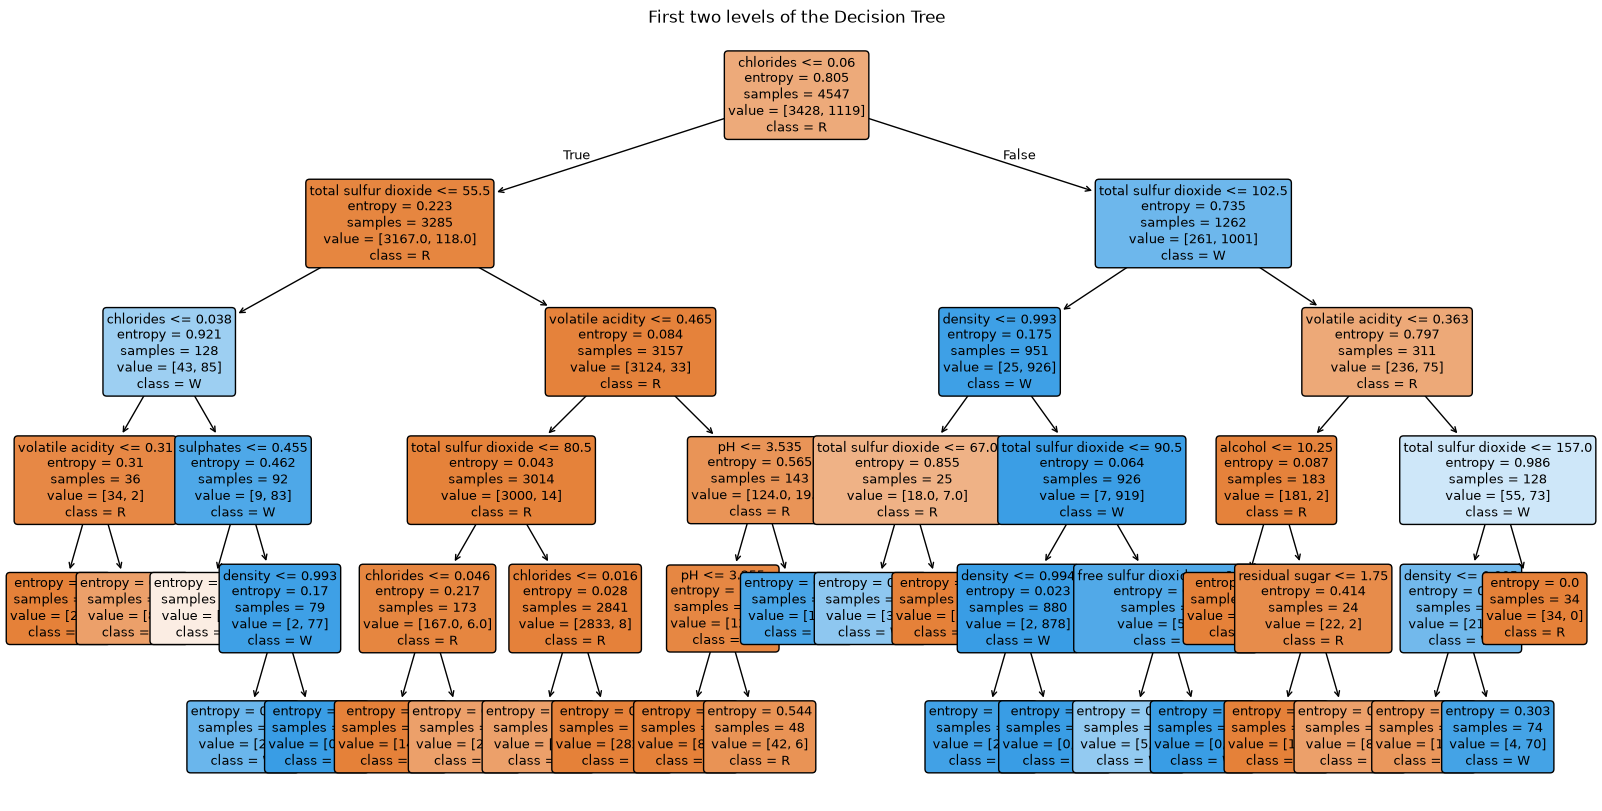

In [54]:
plt.figure(figsize=(20,10))
plot_tree(model, max_depth=10, feature_names=x.columns, class_names=['R', 'W'], filled=True , rounded=True, fontsize=9)
plt.title("First two levels of the Decision Tree")
plt.show()

### ***Random Forest***

In [55]:
rf_wine_model = RandomForestClassifier(class_weight='balanced', n_estimators=300, max_depth=12, random_state=42)
rf_scores = cross_val_score(rf_wine_model, x_train, y_train, cv=5, scoring='accuracy')
print(f"{'Random Forest':22s} 5-fold CV F1 (good class): mean={rf_scores.mean():.3f}  std={rf_scores.std():.3f}")

Random Forest          5-fold CV F1 (good class): mean=0.994  std=0.003


In [56]:
rf_wine_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [57]:
fitted = {}
fitted['logistic'] = logistic_model
fitted['decision_tree'] = dt_model
fitted['random_forest'] = rf_wine_model

print("Models trained:", list(fitted.keys()))

Models trained: ['logistic', 'decision_tree', 'random_forest']


### **Evaluation**